In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset


In [20]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [4]:
PATCH_SIZE = 16
EMBED_DIM = 128
NUM_HEADS = 4
NUM_ENCODER_BLOCKS = 4
IMG_SIZE = 128
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS = 10

In [16]:
dataset_dir = path

In [9]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [59]:
from torchvision.datasets import ImageFolder
from PIL import Image
import os

class SafeImageFolder(ImageFolder):
    def __getitem__(self, index):
        while True:
            try:
                return super().__getitem__(index)
            except:
                print(f'Skipping corrupt image: {self.samples[index][0]}')
                index += 1  # Skip to next image



In [61]:
from torch.utils.data import random_split
import torch

# Create full dataset from the root directory
full_dataset = SafeImageFolder(root=dataset_dir+'/PetImages', transform=transform)

# Define split sizes
train_size = int(0.8 * len(full_dataset))  # 80% for training
val_size = len(full_dataset) - train_size  # 20% for validation

# Split the dataset
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Get class names
class_names = full_dataset.classes

In [62]:
print (class_names)

['Cat', 'Dog']


 28%|██▊       | 172/625 [00:44<02:07,  3.56it/s]

Skipping corrupt image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/11702.jpg


100%|██████████| 625/625 [02:45<00:00,  3.77it/s]


Skipping corrupt image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg
Epoch 1/10 - Loss: 0.6788, Train Acc: 0.5685, Val Acc: 0.6210


 70%|███████   | 439/625 [00:50<00:20,  9.19it/s]

...

Skipping corrupt image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg
Epoch 9/10 - Loss: 0.4447, Train Acc: 0.7877, Val Acc: 0.7262


 82%|████████▏ | 511/625 [00:57<00:13,  8.70it/s]

Skipping corrupt image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/11702.jpg


100%|██████████| 625/625 [01:10<00:00,  8.83it/s]


Skipping corrupt image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg
Epoch 10/10 - Loss: 0.4259, Train Acc: 0.8002, Val Acc: 0.7284


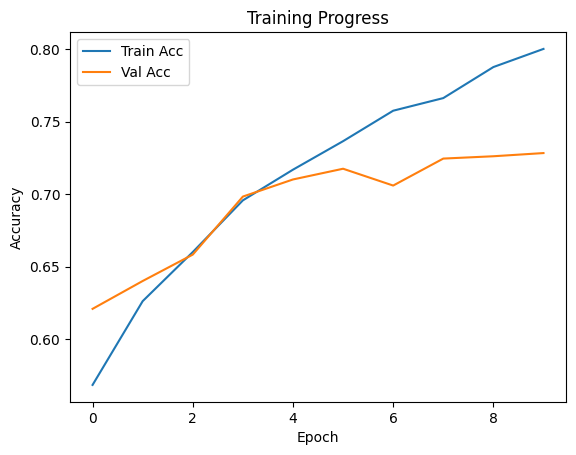

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_ch=3, emb_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
        self.proj = nn.Linear(patch_size * patch_size * in_ch, emb_dim)

    def forward(self, x):
        x = self.unfold(x)  # (B, patch_dim, num_patches)
        x = x.transpose(1, 2)  # (B, num_patches, patch_dim)
        x = self.proj(x)      # (B, num_patches, emb_dim)
        return x

class PositionalEncoding(nn.Module):
    def __init__(self, num_patches, dim):
        super().__init__()
        self.encoding = nn.Parameter(torch.randn(1, num_patches + 1, dim))

    def forward(self, x):
        return x + self.encoding[:, :x.size(1), :]

class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.ff(self.norm2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_ch=3, emb_dim=128, num_heads=4, num_blocks=4, num_classes=2):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_ch, emb_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
        self.pos_enc = PositionalEncoding((img_size // patch_size)**2, emb_dim)
        self.blocks = nn.Sequential(*[TransformerEncoderBlock(emb_dim, num_heads) for _ in range(num_blocks)])
        self.norm = nn.LayerNorm(emb_dim)
        self.head = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)  # (B, num_patches, emb_dim)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.pos_enc(x)
        x = self.blocks(x)
        x = self.norm(x[:, 0])  # CLS token
        return self.head(x)

# Training + Evaluation Functions
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0
    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (pred.argmax(1) == y).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, device):
    model.eval()
    correct = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            all_preds.extend(pred.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            correct += (pred.argmax(1) == y).sum().item()
    return correct / len(loader.dataset), all_preds, all_labels

train_accuracies, val_accuracies = [], []

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ViT(IMG_SIZE, PATCH_SIZE, 3, EMBED_DIM, NUM_HEADS, NUM_ENCODER_BLOCKS, NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_acc, _, _ = evaluate(model, val_loader, device)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Progress")
plt.legend()
plt.show()


Skipping corrupt image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg


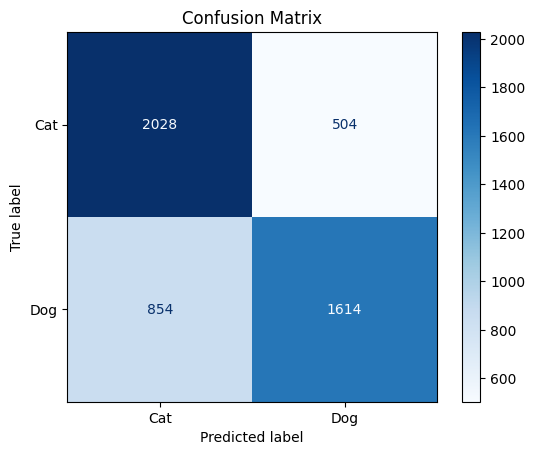

In [66]:
val_acc, preds, labels = evaluate(model, val_loader, device)
cm = confusion_matrix(labels, preds)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [67]:
print(val_acc)

0.7284
